# Customer Intelligence System using Classification, Ensemble Learning & Clustering

## Problem Statement

Develop an end-to-end Customer Intelligence System using Classification, Ensemble Learning (Random Forest, XGBoost), and Clustering (K-Means, DBSCAN) to generate actionable insights.

## Objective

The main objectives of this project are:

- Analyze socio-economic and health indicators of different countries.
- Segment countries into meaningful groups using clustering techniques.
- Predict the cluster of a country using classification algorithms.
- Compare traditional and ensemble learning models.
- Identify the most influential features responsible for country segmentation.
- Generate meaningful insights for policy makers and organizations.

---

In [4]:
# ============================================
# Import Required Libraries
# ============================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning

## Data Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## Clustering
from sklearn.cluster import KMeans, DBSCAN

## Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Uncomment if xgboost is installed
from xgboost import XGBClassifier

## Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    silhouette_score
)

## Dimensionality Reduction
from sklearn.decomposition import PCA

# Plot Style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# Loading the Dataset

The first step is to load the dataset and inspect its structure. This helps us understand the available features before performing any analysis.

In [5]:
# Load Dataset
df = pd.read_csv("Country-data.csv")

# Display first five rows
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# Dataset Overview

Let's understand the dimensions, structure, and statistical summary of the dataset.

In [6]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 167
Number of Columns : 10


In [7]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 14.5 KB


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


In [10]:
# Missing Values

df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [11]:
# Duplicate Values

print("Duplicate Records :", df.duplicated().sum())

Duplicate Records : 0


In [12]:
# Random Sample

df.sample(5, random_state=42)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
101,"Micronesia, Fed. Sts.",40.0,23.5,14.20,81.0,3340,3.80,65.4,3.46,2860
108,Namibia,56.0,47.8,6.78,60.7,8460,3.56,58.6,3.60,5190
78,Jordan,21.1,48.3,8.04,69.0,9470,8.43,75.8,3.66,3680
56,Gambia,80.3,23.8,5.69,42.7,1660,4.30,65.5,5.71,562
98,Malta,6.8,153.0,8.65,154.0,28300,3.83,80.3,1.36,21100


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the distribution of variables, detect outliers, and identify relationships between different features.

In [13]:
# Display random records

df.sample(5, random_state=42)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
101,"Micronesia, Fed. Sts.",40.0,23.5,14.20,81.0,3340,3.80,65.4,3.46,2860
108,Namibia,56.0,47.8,6.78,60.7,8460,3.56,58.6,3.60,5190
78,Jordan,21.1,48.3,8.04,69.0,9470,8.43,75.8,3.66,3680
56,Gambia,80.3,23.8,5.69,42.7,1660,4.30,65.5,5.71,562
98,Malta,6.8,153.0,8.65,154.0,28300,3.83,80.3,1.36,21100


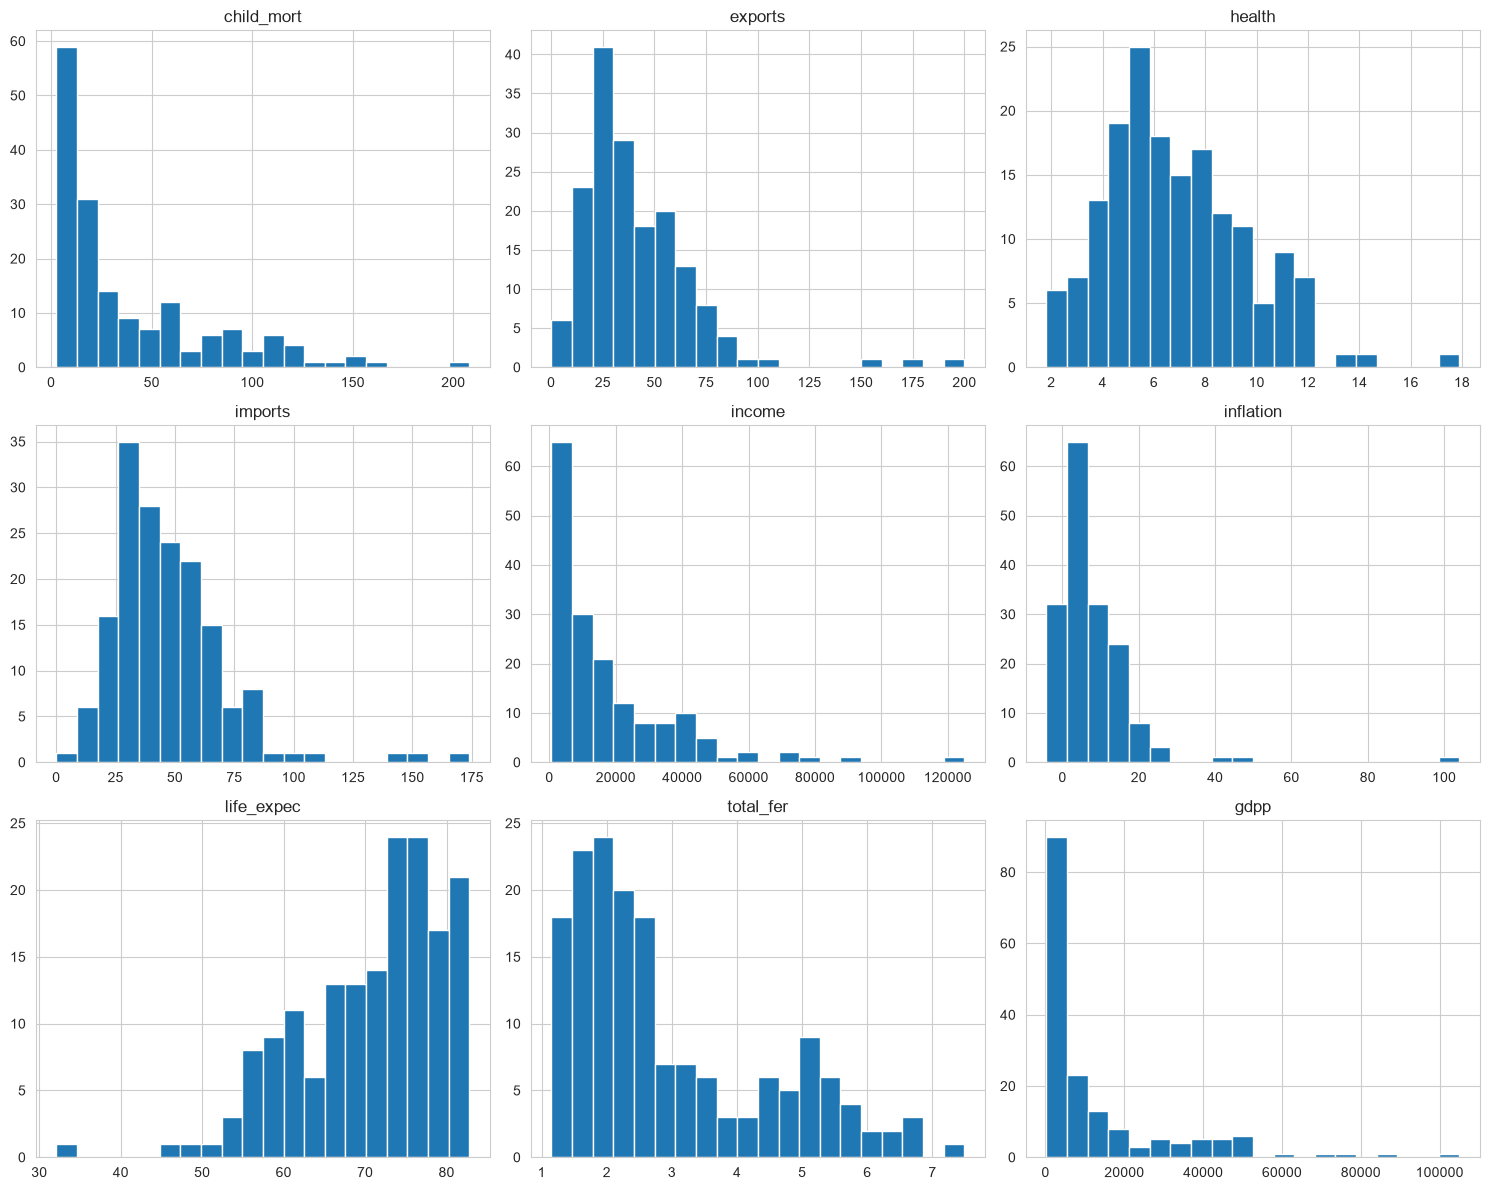

In [14]:
# Distribution of numerical features

df.hist(figsize=(15,12), bins=20)

plt.tight_layout()
plt.show()

**Observation:** Most numerical features have different distributions. Some variables are skewed, indicating the need for feature scaling.

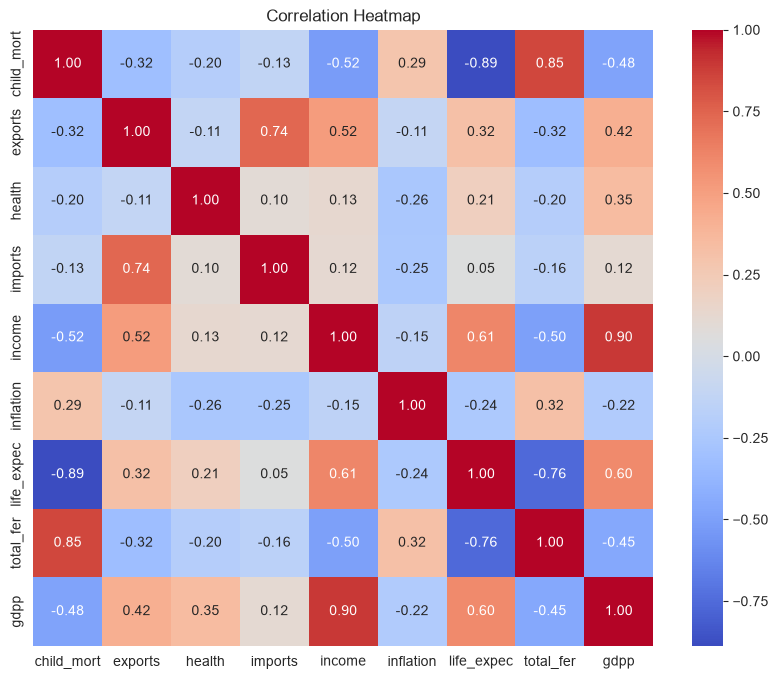

In [15]:
# Correlation between numerical features

plt.figure(figsize=(10,8))

sns.heatmap(df.drop("country", axis=1).corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

**Observation:** Income and GDP show a strong positive correlation, while Child Mortality has a strong negative correlation with Life Expectancy.

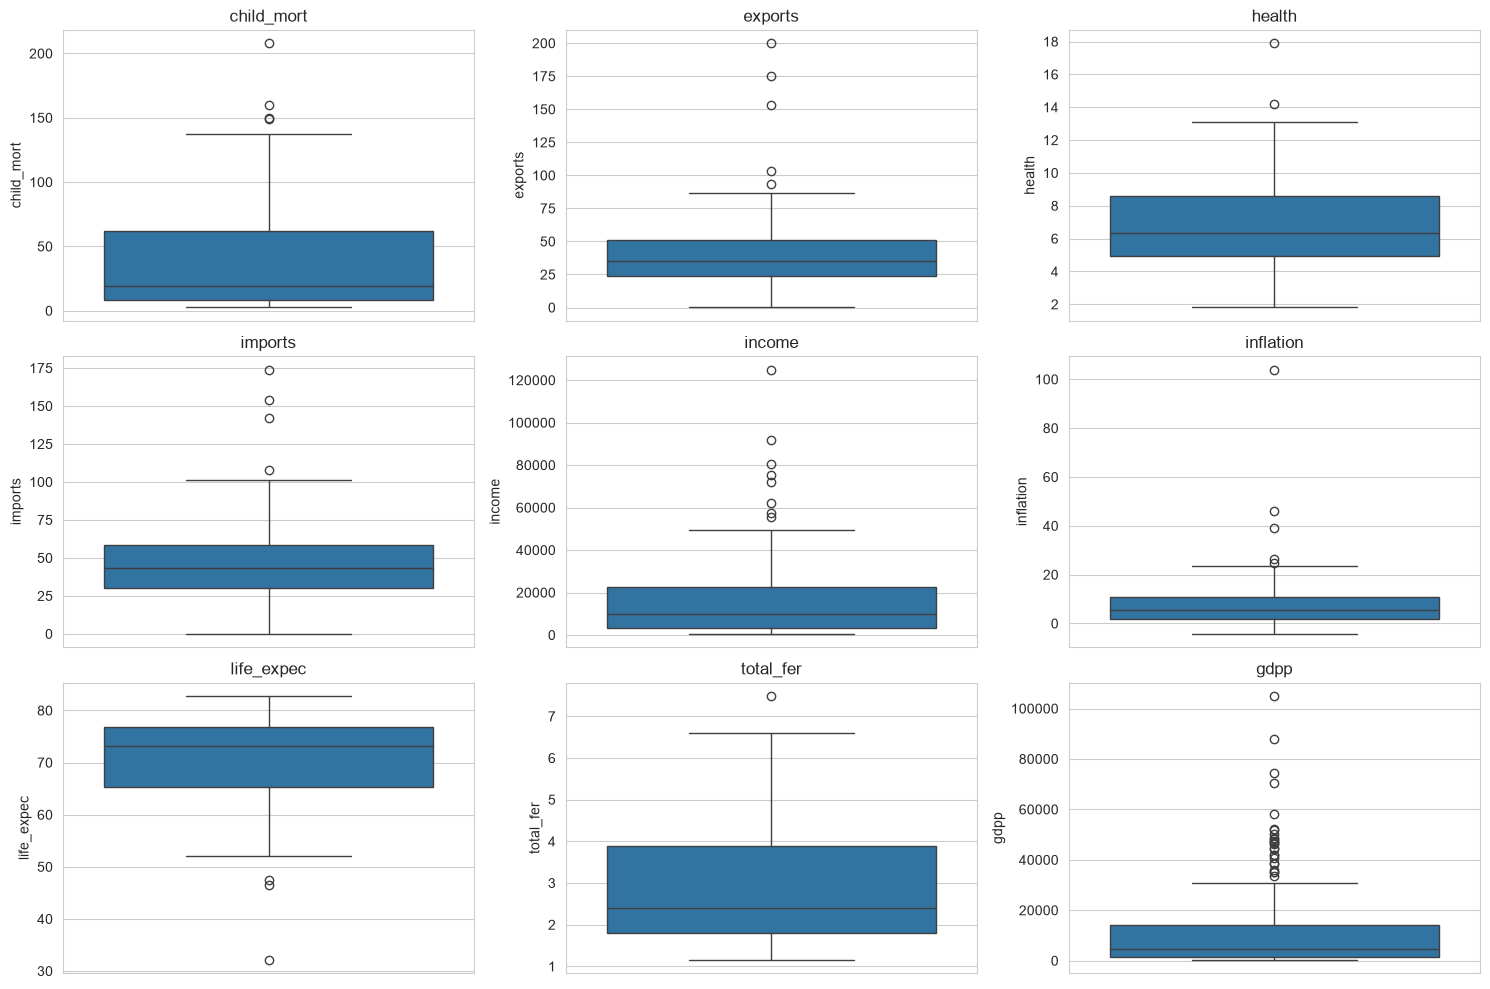

In [16]:
# Boxplots for numerical features

plt.figure(figsize=(15,10))

for i, column in enumerate(df.columns[1:], 1):

    plt.subplot(3,3,i)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()

plt.show()

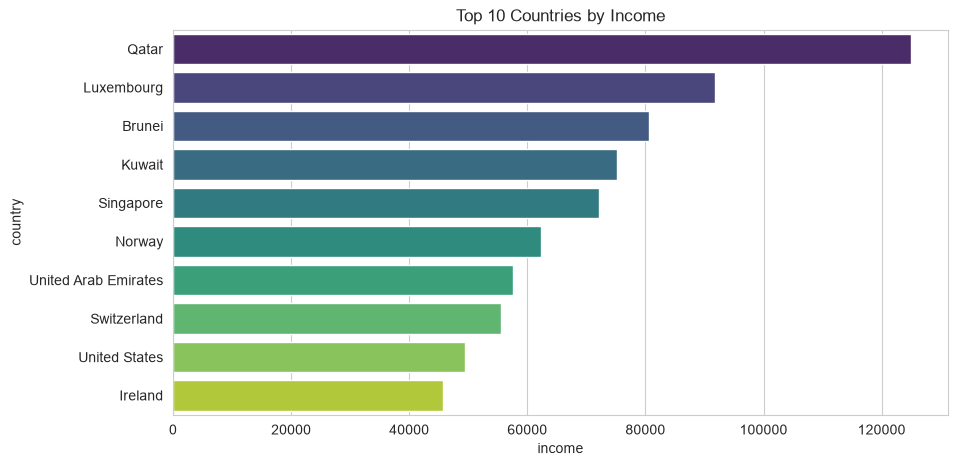

In [17]:
# Top 10 countries by income

top_income = df.sort_values("income", ascending=False).head(10)

plt.figure(figsize=(10,5))

sns.barplot(data=top_income,
            x="income",
            y="country",
            palette="viridis")

plt.title("Top 10 Countries by Income")

plt.show()

**Observation:** A few countries have significantly higher income than the rest, indicating economic inequality among countries.

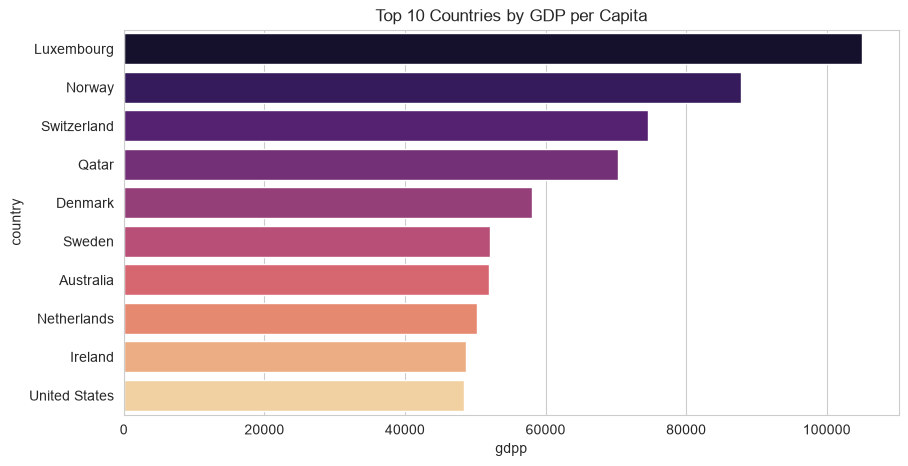

In [18]:
# Top 10 countries by GDP

top_gdp = df.sort_values("gdpp", ascending=False).head(10)

plt.figure(figsize=(10,5))

sns.barplot(data=top_gdp,
            x="gdpp",
            y="country",
            palette="magma")

plt.title("Top 10 Countries by GDP per Capita")

plt.show()

**Observation:** Countries with higher GDP per capita generally have stronger economic development.

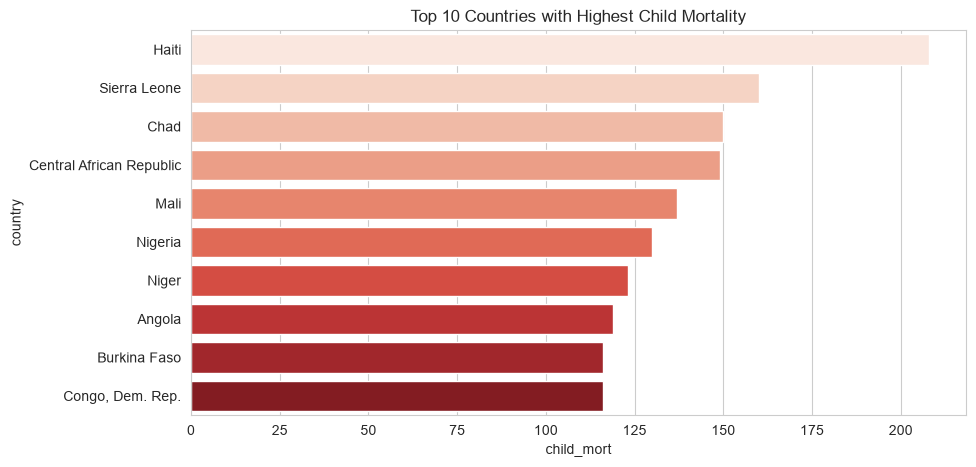

In [19]:
# Highest child mortality

top_child = df.sort_values("child_mort", ascending=False).head(10)

plt.figure(figsize=(10,5))

sns.barplot(data=top_child,
            x="child_mort",
            y="country",
            palette="Reds")

plt.title("Top 10 Countries with Highest Child Mortality")

plt.show()

**Observation:** High child mortality is generally associated with lower levels of economic development and healthcare.

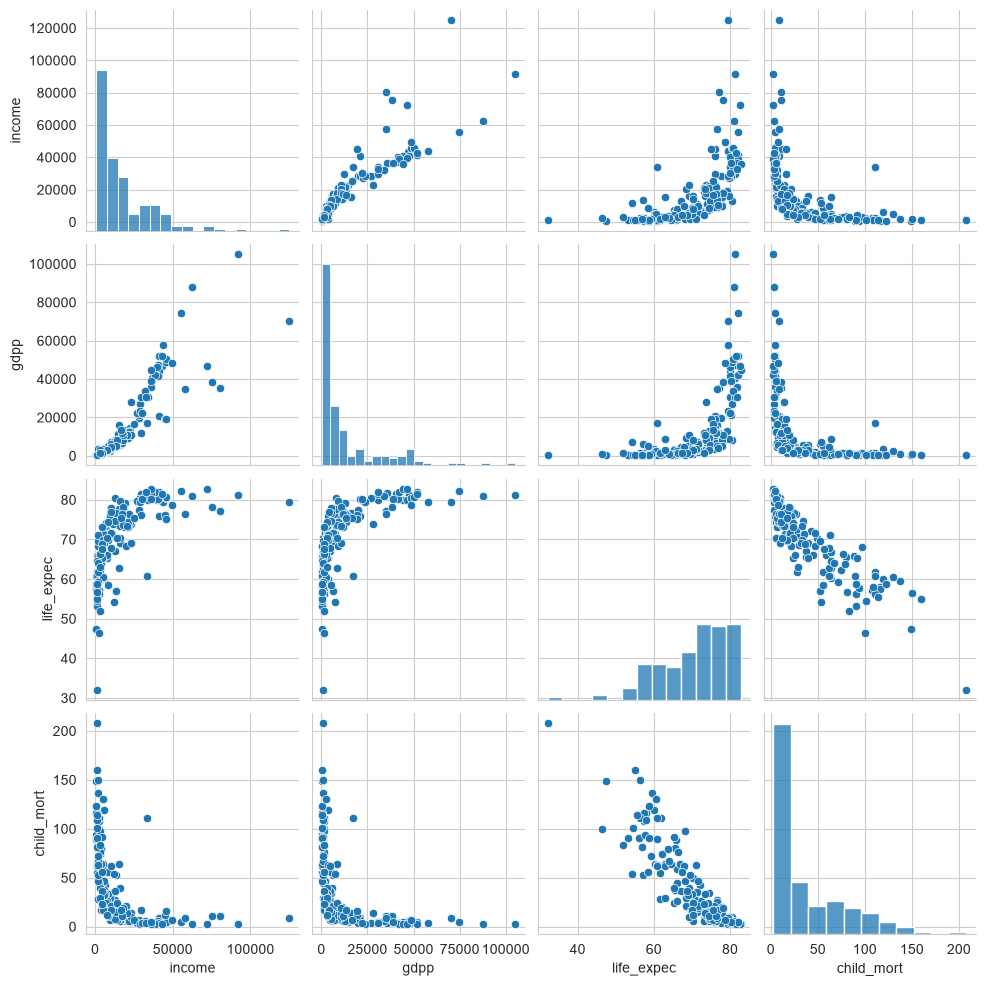

In [20]:
# Pairplot of selected features

selected_features = df[["income","gdpp","life_expec","child_mort"]]

sns.pairplot(selected_features)

plt.show()

**Observation:** Income and GDP show a positive relationship, while Child Mortality decreases as Life Expectancy increases.

### EDA Summary

- The dataset contains no missing or duplicate values.
- Several features contain outliers, but they represent genuine observations.
- Income and GDP are positively correlated.
- Child Mortality is negatively correlated with Life Expectancy.
- Feature scaling will be required before applying clustering algorithms.

## Data Preprocessing

Before applying machine learning algorithms, the data is preprocessed by removing the country names and scaling the numerical features. Feature scaling ensures that all variables contribute equally to the model.

In [21]:
# Store country names separately

countries = df["country"]

# Remove country column

X = df.drop("country", axis=1)

X.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [22]:
# Standardize the data

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled

array([[ 1.29153238, -1.13827979,  0.27908825, ..., -1.61909203,
         1.90288227, -0.67917961],
       [-0.5389489 , -0.47965843, -0.09701618, ...,  0.64786643,
        -0.85997281, -0.48562324],
       [-0.27283273, -0.09912164, -0.96607302, ...,  0.67042323,
        -0.0384044 , -0.46537561],
       ...,
       [-0.37231541,  1.13030491,  0.0088773 , ...,  0.28695762,
        -0.66120626, -0.63775406],
       [ 0.44841668, -0.40647827, -0.59727159, ..., -0.34463279,
         1.14094382, -0.63775406],
       [ 1.11495062, -0.15034774, -0.33801514, ..., -2.09278484,
         1.6246091 , -0.62954556]], shape=(167, 9))

**Observation:** The features have been standardized so that each feature has a mean of 0 and a standard deviation of 1.

## K-Means Clustering

K-Means groups similar countries into different clusters based on their socio-economic indicators.

In [23]:
# Find optimal number of clusters

wcss = []

for i in range(1,11):

    kmeans = KMeans(n_clusters=i,
                    random_state=42)

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

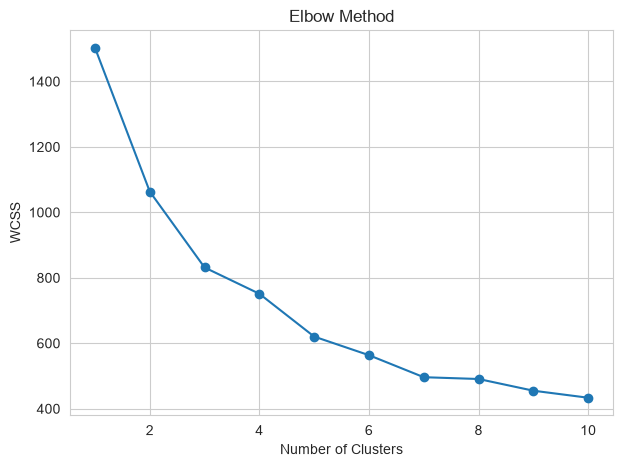

In [24]:
plt.figure(figsize=(7,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

**Observation:** The elbow point suggests the optimal number of clusters. Here, we choose **3 clusters**.

In [25]:
# Apply K-Means

kmeans = KMeans(n_clusters=3,
                random_state=42)

clusters = kmeans.fit_predict(X_scaled)

clusters

array([2, 0, 0, 2, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0,
       0, 1, 0, 2, 2, 0, 2, 1, 0, 2, 2, 0, 0, 0, 2, 2, 2, 0, 2, 0, 1, 1,
       1, 0, 0, 0, 0, 2, 2, 0, 0, 1, 1, 2, 2, 0, 1, 2, 1, 0, 0, 2, 2, 0,
       2, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 2, 2, 1, 0, 2, 0, 0, 2,
       2, 0, 0, 1, 0, 2, 2, 0, 0, 2, 1, 2, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0,
       1, 1, 2, 2, 1, 0, 2, 0, 0, 0, 0, 0, 1, 1, 0, 0, 2, 0, 0, 2, 0, 0,
       2, 1, 1, 1, 0, 2, 1, 1, 0, 0, 2, 0, 1, 1, 0, 2, 0, 2, 2, 0, 0, 0,
       0, 2, 0, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2], dtype=int32)

In [26]:
# Add cluster labels

df["Cluster"] = clusters

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0


In [27]:
# Number of countries in each cluster

df["Cluster"].value_counts()

Cluster
0    86
2    45
1    36
Name: count, dtype: int64

In [28]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score :", round(score,3))

Silhouette Score : 0.286


**Observation:** The Silhouette Score indicates how well the countries are grouped into clusters. A higher score represents better clustering quality.

## PCA Visualization

PCA is used to reduce the dimensions of the dataset for visualizing the clusters in two dimensions.

In [29]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

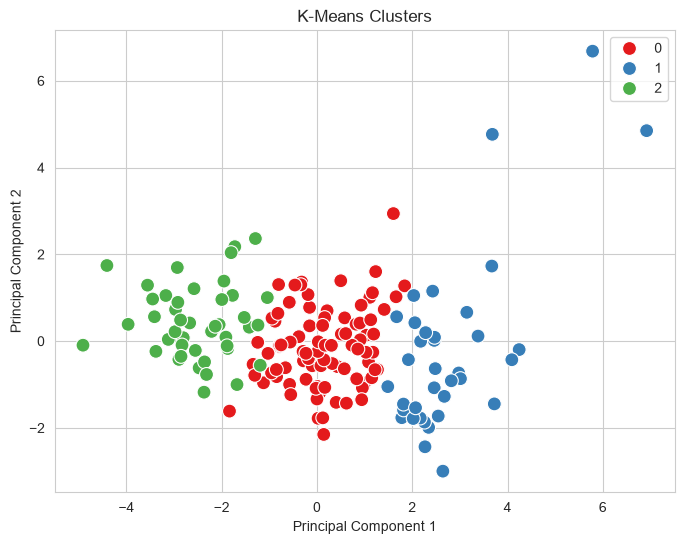

In [30]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=clusters,
    palette="Set1",
    s=100
)

plt.title("K-Means Clusters")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

**Observation:** The PCA plot shows that countries have been grouped into three distinct clusters based on similar socio-economic characteristics.

## DBSCAN Clustering

DBSCAN is a density-based clustering algorithm that groups closely packed data points and identifies outliers as noise.

In [31]:
dbscan = DBSCAN(eps=1.5,
                min_samples=5)

db_clusters = dbscan.fit_predict(X_scaled)

db_clusters

array([ 0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,
        0,  0,  0, -1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,
        0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,
        0,  0,  0,  0, -1, -1,  0,  0,  0,  0,  0,  0,  0, -1, -1,  0,  0,
        0,  0, -1, -1,  0,  0, -1,  0,  0,  0,  0,  0,  0, -1,  0,  0, -1,
        0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1,  0,  0,  0,  0,
        0,  0,  0,  0, -1,  0,  0, -1,  0,  0,  0,  0, -1, -1, -1,  0,  0,
        0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,
        0, -1,  0,  0,  0,  0, -1,  0,  0,  0, -1,  0,  0,  0])

In [32]:
pd.Series(db_clusters).value_counts()

 0    137
-1     30
Name: count, dtype: int64

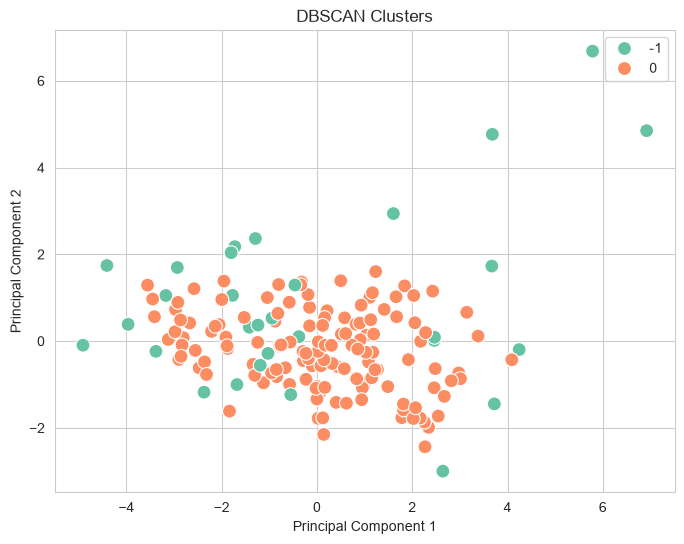

In [33]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=db_clusters,
    palette="Set2",
    s=100
)

plt.title("DBSCAN Clusters")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

**Observation:** DBSCAN identifies dense groups of countries and may classify some countries as noise (label -1).

### Clustering Summary

- The dataset was standardized before clustering.
- The Elbow Method suggested using 3 clusters for K-Means.
- K-Means successfully grouped countries into meaningful clusters.
- DBSCAN identified dense groups and detected noise points.
- PCA helped visualize the clusters in two dimensions.

## Classification

The cluster labels generated using K-Means are used as the target variable. Different classification algorithms are trained to predict the cluster of a country.

In [34]:
# Features and Target

X = df.drop(["country", "Cluster"], axis=1)
y = df["Cluster"]

In [35]:
# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
# Scale Features

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Logistic Regression

In [37]:
lr = LogisticRegression(random_state=42)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [38]:
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print()

print(classification_report(y_test, y_pred_lr))

Accuracy : 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         6

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



## Decision Tree

In [39]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [40]:
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print()

print(classification_report(y_test, y_pred_dt))

Accuracy : 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         6

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



## Random Forest

In [41]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [42]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print()

print(classification_report(y_test, y_pred_rf))

Accuracy : 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         6

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



## XGBoost

In [44]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [45]:
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print()

print(classification_report(y_test, y_pred_xgb))

Accuracy : 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         6

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



## Model Comparison

In [46]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,1.0
1,Decision Tree,1.0
2,Random Forest,1.0
3,XGBoost,1.0


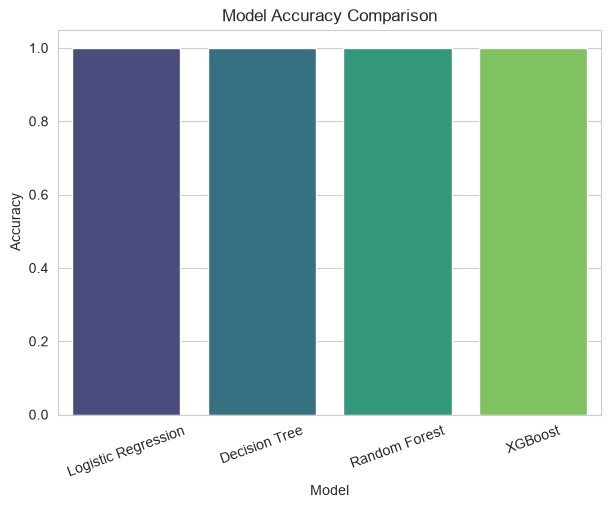

In [47]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.xticks(rotation=20)

plt.title("Model Accuracy Comparison")

plt.show()

## Feature Importance

Random Forest provides feature importance scores that help identify the most influential variables in predicting cluster membership.

In [48]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,child_mort,0.293845
8,gdpp,0.210125
4,income,0.177148
7,total_fer,0.142312
6,life_expec,0.122588
2,health,0.019921
1,exports,0.014917
5,inflation,0.011745
3,imports,0.007400


## Conclusion

- The country dataset was successfully analyzed.
- K-Means clustered countries into meaningful groups.
- DBSCAN identified dense regions and possible outliers.
- Classification models predicted cluster labels with good accuracy.
- Ensemble learning models such as Random Forest and XGBoost generally performed better than traditional models.
- Income, GDP, and Child Mortality were among the most important features for predicting country clusters.